In [28]:
# Scoring
from sklearn.pipeline import make_pipeline
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Pre-proc
from sklearn import preprocessing

# Data Balance
"""
`pip install imbalanced-learn`
Ref: https://towardsdatascience.com/how-to-balance-a-dataset-in-python-36dff9d12704
"""
from imblearn.pipeline import make_pipeline as make_pipeline_imb
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced

# Plot
import matplotlib.pyplot as plt
import matplotlib

# Utils
from collections import Counter
import numpy as np
import pandas as pd

# Classifiers
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

In [4]:
prev_df = pd.read_csv('../previsions.csv', delimiter=',')
prev_df.head()

,dem,CDSEXE,MTREV,NBENF,AGEAD,CDTMT_0,CDTMT_2,CDTMT_4,CDTMT_6,CDSITFAM_A,...,CDCATCL_22,CDCATCL_23,CDCATCL_24,CDCATCL_25,CDCATCL_32,CDCATCL_40,CDCATCL_50,CDCATCL_61,CDCATCL_82,CDCATCL_98
0,1,2,0,0,33,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,2,0,0,55,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,2,0,0,39,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,3,0,0,29,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,2,0,0,45,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [5]:
users_array = prev_df.to_numpy()
average_drop_rate = (np.mean([i[0] for i in users_array]) * 100)

X = users_array[:, 1:]
Y = users_array[:, 0]

# Statisctics about the data transormation

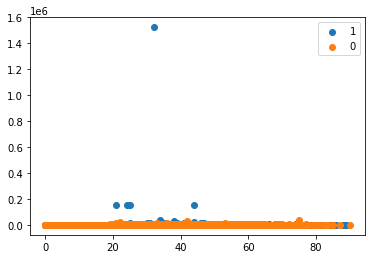

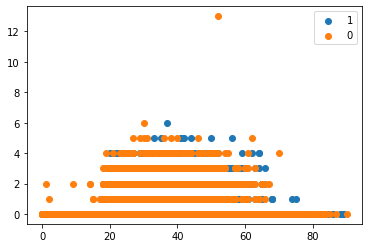

Distribution normale : Counter({1: 30880, 0: 14474})


In [6]:
# https://machinelearningmastery.com/undersampling-algorithms-for-imbalanced-classification/

counter = Counter(Y)

# Agead / MtRev
for label, _ in counter.items():
    row_ix = np.where(Y == label)[0]
    plt.scatter(X[row_ix, 3], X[row_ix, 1], label=str(label))
plt.legend()
plt.show()

# Agead / NbEnf
for label, _ in counter.items():
    row_ix = np.where(Y == label)[0]
    plt.scatter(X[row_ix, 3], X[row_ix, 2], label=str(label))
plt.legend()
plt.show()

print(f"Distribution normale : {counter}")

## Near Miss

Note: l'execution prends trop de temps pour mon PC

In [7]:
# X_nearmiss, y_nearmiss = NearMiss(version=2, n_neighbors=3).fit_resample(X, Y)

# counter = Counter(y_nearmiss)

# Agead / NbEnf
# for label, _ in counter.items():
#     row_ix = np.where(y_nearmiss == label)[0]
#     plt.scatter(X_nearmiss[row_ix, 3], X_nearmiss[row_ix, 2], label=str(label))
# plt.legend()
# plt.show()

# print(f"Sous-échantillonnage / distribution NearMiss : {Counter(y_nearmiss)}")



# Modèles

In [8]:
lr_model = LogisticRegression
svm_model = SVC()

## Modèle 80/20 Régression Linéaire

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

pipeline = make_pipeline(lr_model(random_state=42))
model = pipeline.fit(X_train, y_train)
prediction = model.predict(X_test)

print(f'Score de la Régression Linéaire sans distribution {pipeline.score(X_test, y_test)}')

Précision de la Régression Linéaire sans distribution 0.9194135155991622


### NearMiss sur modèle 80/20 Régression Linéaire

In [10]:
# NM_X_train, NM_X_test, NM_y_train, NM_y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
#
# NM_pipeline = make_pipeline_imb(NearMiss(random_state=42), lr_model(random_state=42))
# NM_model = NM_pipeline.fit(NM_X_train, NM_y_train)
# NM_prediction = NM_model.predict(NM_X_test)

# print(f'Précision de la Régression Linéaire avec Sous-échantillonnage NearMiss {NM_pipeline.score(X_test, y_test)}')


### Indicateurs de classification

In [11]:
accuracy = accuracy_score(y_test, prediction)
precision = precision_score(y_test, prediction)
recall = recall_score(y_test, prediction)
f1 = f1_score(y_test, prediction)

print(f"""
Classification par défaut
Exactitude   : {accuracy}
Précision    : {precision}
Ratio Rappel : {recall}
F-score      : {f1}
""")



Classification par défaut
Exactitude   : 0.9194135155991622
Précision    : 0.9150596877869606
Ratio Rappel : 0.9714053614947198
F-score      : 0.9423910473638586



## Modèle 80/20 Support Vector Machine

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

pipeline = make_pipeline(svm_model)
model = pipeline.fit(X_train, y_train)
prediction = model.predict(X_test)

print(f'Score de SVM sans distribution {pipeline.score(X_test, y_test)}')

Score de SVM sans distribution 0.7127108367324441


### NearMiss sur modèle 80/20 Support Vecteur Machine

In [ ]:
# NM_X_train, NM_X_test, NM_y_train, NM_y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
#
# NM_pipeline = make_pipeline_imb(NearMiss(random_state=42), lr_model(random_state=42))
# NM_model = NM_pipeline.fit(NM_X_train, NM_y_train)
# NM_prediction = NM_model.predict(NM_X_test)

# print(f'Précision de Support Vecteur Machine avec Sous-échantillonnage NearMiss {NM_pipeline.score(X_test, y_test)}')


### Indicateurs de classification

In [13]:
accuracy = accuracy_score(y_test, prediction)
precision = precision_score(y_test, prediction)
recall = recall_score(y_test, prediction)
f1 = f1_score(y_test, prediction)

print(f"""
Classification par défaut
Exactitude   : {accuracy}
Précision    : {precision}
Ratio Rappel : {recall}
F-score      : {f1}
""")


Classification par défaut
Exactitude   : 0.7127108367324441
Précision    : 0.7353136188834372
Ratio Rappel : 0.90089358245329
F-score      : 0.8097254672897197



# Mise à l'échelle et Normalisation
## Régression Linéaire

In [24]:
min_max = preprocessing.MinMaxScaler()
X_minmax = min_max.fit_transform(X)

std_scale = preprocessing.StandardScaler()
X_scale = std_scale.fit_transform(X)

X_l1 = preprocessing.normalize(X, norm="l1")
X_l2 = preprocessing.normalize(X, norm="l2")

### Calcul de la MAE, MSE, RMSE sur une Régression Linéaire

https://towardsdatascience.com/linear-regression-in-python-9a1f5f000606
https://scikit-learn.org/stable/modules/model_evaluation.html#mean-squared-error

In [30]:
def get_lr_model(X_dat):
    X_train, X_test, y_train, y_test = train_test_split(X_dat, Y, test_size=0.2, random_state=42)
    pipeline = make_pipeline(lr_model())
    model = pipeline.fit(X_train, y_train)
    return X_test, y_test, model

X_test, y_test, model = get_lr_model(X)
prediction = model.predict(X_test)
print(f"MAE sur une Régression Linéaire sans normalisation {mean_absolute_error(y_test, prediction)}")
print(f"MSE sur une Régression Linéaire sans normalisation {mean_squared_error(y_test, prediction)}")
print(f"RMSE sur une Régression Linéaire sans normalisation {np.sqrt(mean_squared_error(y_test, prediction))}")
print("")

# X_test, y_test, model = get_lr_model(X_minmax)
# prediction = model.predict(X_test)
# print(f"MSE sur une Régression Linéaire avec MinMax {mean_squared_error(y_test, prediction)}")
#
X_test, y_test, model = get_lr_model(X_scale)
prediction = model.predict(X_test)
print(f"MAE sur une Régression Linéaire avec Répartitions Normales {mean_absolute_error(y_test, prediction)}")
print(f"MSE sur une Régression Linéaire avec Répartitions Normales {mean_squared_error(y_test, prediction)}")
print(f"RMSE sur une Régression Linéaire avec Répartitions Normales {np.sqrt(mean_squared_error(y_test, prediction))}")
print("")

X_test, y_test, model = get_lr_model(X_l1)
prediction = model.predict(X_test)
print(f"MAE sur une Régression Linéaire avec Normalisation L1 {mean_absolute_error(y_test, prediction)}")
print(f"MSE sur une Régression Linéaire avec Normalisation L1 {mean_squared_error(y_test, prediction)}")
print(f"RMSE sur une Régression Linéaire avec Normalisation L1 {np.sqrt(mean_squared_error(y_test, prediction))}")
print("")

X_test, y_test, model = get_lr_model(X_l2)
prediction = model.predict(X_test)
print(f"MAE sur une Régression Linéaire avec Normalisation L2 {mean_absolute_error(y_test, prediction)}")
print(f"MSE sur une Régression Linéaire avec Normalisation L2 {mean_squared_error(y_test, prediction)}")
print(f"RMSE sur une Régression Linéaire avec Normalisation L2 {np.sqrt(mean_squared_error(y_test, prediction))}")
print("")

MAE sur une Régression Linéaire sans normalisation 0.08058648440083784
MSE sur une Régression Linéaire sans normalisation 0.08058648440083784
RMSE sur une Régression Linéaire sans normalisation 0.2838775869998155

MAE sur une Régression Linéaire avec Répartitions Normales 0.0743027229632896
MSE sur une Régression Linéaire avec Répartitions Normales 0.0743027229632896
RMSE sur une Régression Linéaire avec Répartitions Normales 0.27258525815474616

MAE sur une Régression Linéaire avec Normalisation L1 0.15830669165472386
MSE sur une Régression Linéaire avec Normalisation L1 0.15830669165472386
RMSE sur une Régression Linéaire avec Normalisation L1 0.3978777345551317

MAE sur une Régression Linéaire avec Normalisation L2 0.15301510307573585
MSE sur une Régression Linéaire avec Normalisation L2 0.15301510307573585
RMSE sur une Régression Linéaire avec Normalisation L2 0.39117144971960294



### Exactitude après normaliastion et mise à l'échelle

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

pipeline = make_pipeline(lr_model(random_state=42))
model = pipeline.fit(X_train, y_train)
prediction = model.predict(X_test)

print(f'Exactitude de la Régression Linéaire sans distribution {pipeline.score(X_test, y_test)}')

# X_train, X_test, y_train, y_test = train_test_split(X_minmax, Y, test_size=0.2, random_state=42)
#
# pipeline = make_pipeline(lr_model(random_state=42))
# model = pipeline.fit(X_train, y_train)
# prediction = model.predict(X_test)
#
# print(f'Exactitude de la Régression Linéaire avec MinMax {pipeline.score(X_test, y_test)}')

X_train, X_test, y_train, y_test = train_test_split(X_scale, Y, test_size=0.2, random_state=42)

pipeline = make_pipeline(lr_model(random_state=42))
model = pipeline.fit(X_train, y_train)
prediction = model.predict(X_test)

print(f'Exactitude de la Régression Linéaire avec Répartitions Normales {pipeline.score(X_test, y_test)}')

X_train, X_test, y_train, y_test = train_test_split(X_l1, Y, test_size=0.2, random_state=42)

pipeline = make_pipeline(lr_model(random_state=42))
model = pipeline.fit(X_train, y_train)
prediction = model.predict(X_test)

print(f'Exactitude de la Régression Linéaire avec Normalisation L1 {pipeline.score(X_test, y_test)}')

X_train, X_test, y_train, y_test = train_test_split(X_l2, Y, test_size=0.2, random_state=42)

pipeline = make_pipeline(lr_model(random_state=42))
model = pipeline.fit(X_train, y_train)
prediction = model.predict(X_test)

print(f'Exactitude de la Régression Linéaire avec Normalisation L2 {pipeline.score(X_test, y_test)}')



Exactitude de la Régression Linéaire sans distribution 0.9194135155991622
Exactitude de la Régression Linéaire avec Répartitions Normales 0.9256972770367103
Exactitude de la Régression Linéaire avec Normalisation L1 0.8416933083452761
Exactitude de la Régression Linéaire avec Normalisation L2 0.8469848969242642


## Support Vecteur Machine

Note: j'ai pris la décision de ne *pas* réaliser ces tests en raison de mon toaster

In [ ]:
# TODO: code

# Validation Croisée

## Validation en 10-étapes (kFolds)
On fixe la valeur de k à k=10, qui est connue pour être la plus compêtante en général.
Source: https://machinelearningmastery.com/k-fold-cross-validation/

In [36]:
from sklearn.model_selection import cross_val_score

model = lr_model()
scores = cross_val_score(model, X_scale, Y, cv=10)
scores_precision = cross_val_score(model, X_scale, Y, cv=10, scoring='precision')
scores_recall = cross_val_score(model, X_scale, Y, cv=10, scoring='recall')
scores_f1 = cross_val_score(model, X_scale, Y, cv=10, scoring='f1')
print(f"""
Évaluation de la Régression Linéaire sous Validation Croisée 10-étapes

Exactitude   : {scores.mean():.3f} (+/- {scores.std() * 2:.3f})
Précision    : {scores_precision.mean():.3f} (+/- {scores_precision.std() * 2:.3f})
Ratio Rappel : {scores_recall.mean():.3f} (+/- {scores_recall.std() * 2:.3f})
F-score      : {scores_f1.mean():.3f} (+/- {scores_f1.std() * 2:.3f})
""")


Évaluation de la Régression Linéaire sous Validation Croisée 10-étapes

Exactitude   : 0.921 (+/- 0.082)
Précision    : 0.924 (+/- 0.083)
Ratio Rappel : 0.966 (+/- 0.041)
F-score      : 0.944 (+/- 0.058)

Exactitude de la Régression Linéaire sous Validation Croisée 10-étapes 0.921 (+/- 0.082)


In [38]:
# Je n'ai volontairement pas executé les calculs suivants afin de ne pas achever mon toaster

lsvm_model = SVC()
scores = cross_val_score(lsvm_model, X_scale, Y, cv=10)
scores_precision = cross_val_score(lsvm_model, X_scale, Y, cv=10, scoring='precision')
scores_recall = cross_val_score(lsvm_model, X_scale, Y, cv=10, scoring='recall')
scores_f1 = cross_val_score(lsvm_model, X_scale, Y, cv=10, scoring='f1')
print(f"""
Évaluation du Support Vecteur Machine sous Validation Croisée 10-étapes

Exactitude   : {scores.mean():.3f} (+/- {scores.std() * 2:.3f})
Précision    : {scores_precision.mean():.3f} (+/- {scores_precision.std() * 2:.3f})
Ratio Rappel : {scores_recall.mean():.3f} (+/- {scores_recall.std() * 2:.3f})
F-score      : {scores_f1.mean():.3f} (+/- {scores_f1.std() * 2:.3f})
""")

KeyboardInterrupt: 